In [1]:
# slow import
import adaptive_polish.gis_measurement as gm

c:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\code\adaptive_polish\.conda\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.23 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
# imports

import logging
import string
import json
from enum import Enum
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import PIL
import tifffile

import typing
from numpy.typing import NDArray, DTypeLike

In [3]:
class NoImageFound(FileNotFoundError):
    pass


class NoExperimentFound(NoImageFound):
    pass

In [4]:
# Constants
CONTINUE_FILENAME_STRING = "mill"
STOP_FILENAME_STRING = "stop"

max_crack_area_m2 = 2e-12
gis_stop_m = 5e-7
gis_full_power_m = 2e-6
window_size_m = 1e-7

base_path = Path.home() / "OneDrive - The Rosalind Franklin Institute" / "Documents" / "test data" / "adaptive milling" / "2024segmentation_testdata"
model_path = base_path / "2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp"
results_json_path = base_path / "results.json"
results_plots_path = base_path / "results_plots.png"

In [5]:
logging.info("Initialising DL model, path: %s", model_path)
gm.init_model_with_path(model_path)

In [6]:
def get_array_and_pixel_size(image_path: Path) -> tuple[NDArray[typing.Any], float]:
    with tifffile.TiffFile(image_path) as tif:
        image_array = tif.asarray()
        # TODO: What's going on with the metadata?
        # pixel_size_m = tif.fei_metadata
        return image_array, tif.shaped_metadata[0]["pixel_size"]["x"]

In [7]:
@dataclass
class TestImageInfo:
    path: Path
    data: NDArray[typing.Any]
    pixel_size_m: float
    expect_continue_milling: bool
    results: dict[str, typing.Any] = field(default_factory=dict)

class StrEnum(str, Enum):

    def __str__(self):
        return str(self.value)


class MillingDecision(StrEnum):
    Mill = "milling should continue"
    StopNoCleanPrediction = "no clean prediction"
    StopNoGISLayer = "no GIS layer detected"
    StopTooThinGISLayer = "minimum GIS thickness below threshold"
    StopCrackFound = "crack with area above threshold found"


class AdaptiveMillingTestResult(StrEnum):
    SUCCESS = "success"
    FAILED_TO_STOP = "failed to stop"
    FAILED_TO_CONTINUE = "failed to continue"

In [8]:
def measure_GIS_modified(
    mask_gis_clean: np.array, window_size_m: int, pixel_size_m: float
) -> np.array:
    # Get window size in px
    window_size_px = int(window_size_m / pixel_size_m)
    logging.info(f"window_size_px: {window_size_px}")

    # Calculate average GIS thickness in windows

    # Sum to get thickness along x in pixels
    GIS_pxbypx = np.sum(mask_gis_clean, axis=0).astype(np.float32)

    # Pad with zeros to fulfil window size criteria
    GIS_pxbypx_pad = np.pad(
        GIS_pxbypx,
        (0, window_size_px - len(GIS_pxbypx) % window_size_px),
        constant_values=np.nan,
    )

    # Get left and right limits from where the mean should be calculated from
    GIS_pxbypx_where_above_zero = np.where(GIS_pxbypx_pad > 0)
    xlim_min = GIS_pxbypx_where_above_zero[0][0]  # first occurrence along x
    xlim_max = GIS_pxbypx_where_above_zero[0][-1]  # last occurrence along x

    # make the L and R limits of the lamella x% smaller
    lamella_width_px = xlim_max - xlim_min
    lamella_width_to_cut = int(0.05 * lamella_width_px)  # cut 5% from each end
    xlim_min = lamella_width_to_cut + xlim_min
    xlim_max = xlim_max - lamella_width_to_cut

    GIS_pxbypx_NaNed = np.copy(GIS_pxbypx_pad).astype(np.float32)
    GIS_pxbypx_NaNed[:xlim_min] = np.nan
    GIS_pxbypx_NaNed[xlim_max:] = np.nan

    # This mean will discard nan areas
    # GIS_windowed = np.nanmedian(GIS_pxbypx_NaNed.reshape(-1, window_size_px), axis=1)
    stack = [
        GIS_pxbypx_NaNed[_ : _ + window_size_px]
        for _ in range(GIS_pxbypx_NaNed.size - window_size_px)
    ]
    GIS_windowed = np.nanmedian(
        stack,
        axis=1,
    )
    # Convert to m
    GIS_m = GIS_windowed * pixel_size_m

    # Make any value with 0's, i.e. no GIS measured, NaNs
    GIS_m[np.where(GIS_m == 0)] = np.nan

    return GIS_m, (xlim_min, xlim_max)

In [9]:
def generate_milling_bitmap(
    gis_m: NDArray[np.floating],
    gis_stop_m: float,
    gis_full_power_m: float,
    gis_resolution_m: typing.Union[float, None] = None,
    bitmap_resolution_m: typing.Union[float, None] = None,
    dtype: DTypeLike = np.uint8,
    nan_value: float = 0
) -> NDArray[typing.Any]:
    """
    Strength multiplier should be between 0 and 1

    If bitmap_resolution_m and gis_resolution_m are None, no pixel interpolation is used.
    """
    dt = np.dtype(dtype)

    assert np.issubdtype(dt, np.integer), "Only integer dtypes accepted"

    n = len(gis_m)
    if gis_resolution_m is None and bitmap_resolution_m is None:
        factor = 1
    elif gis_full_power_m is not None and bitmap_resolution_m is not None:
        factor = bitmap_resolution_m / gis_resolution_m
    else:
        raise TypeError("gis_resolution_m and bitmap_resolution_m must both be None or floats, the types cannot be mixed")

    x = np.linspace(0, n - 1, (n - 1) * factor + 1)
    gis_m = gis_m.copy()
    gis_m[np.isnan(gis_m)] = nan_value
    interpolated = np.interp(x, range(n), gis_m)

    # Rescale to uint8 (clips to 0 at gis_stop_m and 255 at gis_full_power_m)
    rescaled = (
        np.round(
            np.interp(
                interpolated,
                (gis_stop_m, gis_full_power_m),
                (np.iinfo(dt).min, np.iinfo(dt).max),
            )
        )
        .astype(dt)
        .reshape(1, -1)
    )

    return rescaled

In [10]:
def process_SEM_image(sem_image_info: TestImageInfo, window_size_m: float) -> tuple[MillingDecision,...]:
    decision_reasons = []

    # Segmentation
    logging.info("Starting segmentation")
    prediction = gm.segment(sem_image_info.data)
    logging.info("Segmentation complete")

    mask_gis_clean = gm.clean_prediction(
        prediction,
        sem_image_info.pixel_size_m,
    )
    logging.info("Finished cleaning mask")

    if mask_gis_clean is None:
        logging.info("mask_gis_clean is None. Stopping")
        decision_reasons.append(MillingDecision.StopNoCleanPrediction)
    # Is there any GIS?
    if not np.any(mask_gis_clean):
        # No GIS detected
        logging.info("No GIS layer detected in mask_gis_clean. Stopping")
        decision_reasons.append(MillingDecision.StopNoGISLayer)
    else:
        # GIS thickness measurement
        GIS_m, xlims = measure_GIS_modified(
            mask_gis_clean,
            window_size_m,
            float(sem_image_info.pixel_size_m),
        )
        min_GIS_m = np.nanmin(GIS_m)
        logging.info(f"Took {len(GIS_m)} GIS measurements along x")
        logging.info(
            "Minimum GIS thickness for milling cycle %s = %f m2",
            sem_image_info.path,
            min_GIS_m,
        )

        # Should we continue?
        if min_GIS_m < float(gis_stop_m):
            logging.info(
                f"Stopping as minimum GIS (m) {min_GIS_m} < threshold {gis_stop_m}"
            )
            decision_reasons.append(MillingDecision.StopTooThinGISLayer)

        # Crack detection
        crack_area_m2 = gm.get_crack_area_m2(prediction, sem_image_info.pixel_size_m)

        logging.info(
            "Area of cracks found in %s = %f m2", sem_image_info.path, crack_area_m2
        )

        if crack_area_m2 > float(max_crack_area_m2):
            logging.info(
                f"Stopping as crack area (m2) {crack_area_m2} > threshold {max_crack_area_m2}"
            )
            decision_reasons.append(MillingDecision.StopCrackFound)

        sem_image_info.results["GIS_m"] = GIS_m
        sem_image_info.results["xlims"] = xlims
        sem_image_info.results["crack_area_m2"] = crack_area_m2

    sem_image_info.results["prediction"] = prediction
    sem_image_info.results["mask_gis_clean"] = mask_gis_clean

    if not decision_reasons:
        decision_reasons.append(MillingDecision.Mill)

    return tuple(decision_reasons)

In [11]:
def process_images(sem_image_info: TestImageInfo, fib_image_info: TestImageInfo, plot_basename:str) -> tuple[MillingDecision,...]:
    stop_milling_reasons = process_SEM_image(sem_image_info, window_size_m=window_size_m)
    logging.info(f"Saving {plot_basename}_plot.png")
    plot_dir = base_path / "plots" / "modified_GIS_m"
    gis_m = sem_image_info.results.get("GIS_m")
    gm.milling_cycle_plot(
        sem_image=sem_image_info.data,
        first_prediction=sem_image_info.results["prediction"],
        clean_prediction=sem_image_info.results["mask_gis_clean"],
        fib_image=fib_image_info.data,
        gis_thickness_m=gis_m,
        gis_stop_m=gis_stop_m,
        crack_area_m2=sem_image_info.results.get("crack_area_m2"),
        img_name=plot_basename,
        fib_screenshot=None,
        save_path=plot_dir / f"{plot_basename}_plot.png"
    )
    if gis_m is not None:
        xlims = sem_image_info.results["xlims"]
        PIL.Image.fromarray(
            generate_milling_bitmap(
                sem_image_info.results.get("GIS_m")[xlims[0]: xlims[1]],
                gis_stop_m=gis_stop_m,
                gis_full_power_m=gis_full_power_m,
                dtype=np.uint8,
            )
    ).save(plot_dir / f"{plot_basename}_mill.bmp", format="BMP")
    return stop_milling_reasons


def get_step_info(
    directory_path: Path, index: int, step_char: str, image_type: str
) -> TestImageInfo:
    file_stem = f"{index:02d}{step_char}_{image_type}"
    continue_path = directory_path / f"{file_stem}_{CONTINUE_FILENAME_STRING}.tif"
    stop_path = directory_path / f"{file_stem}_{STOP_FILENAME_STRING}.tif"
    if continue_path.is_file():
        image_path = continue_path
        expect_continue = True
    elif stop_path.is_file():
        image_path = stop_path
        expect_continue = False
    else:
        raise NoImageFound(f"No image found for {file_stem}")

    image_array, pixel_size_m = get_array_and_pixel_size(image_path)

    return TestImageInfo(image_path, image_array, pixel_size_m, expect_continue)

In [12]:
def process_experiment_step(
    fib_path: Path, sem_path: Path, index: int, step_char: str
) -> tuple[AdaptiveMillingTestResult, tuple[MillingDecision, ...]]:
    sem_image_info = get_step_info(sem_path, index, step_char, "SEM")
    fib_image_info = get_step_info(fib_path, index, step_char, "FIB")
    assert (
        sem_image_info.expect_continue_milling
        == fib_image_info.expect_continue_milling
    ), "Milling continue or stop does not match between SEM and FIB images"

    milling_decisions = process_images(sem_image_info, fib_image_info, f"{index:02d}{step_char}")
    continue_milling = milling_decisions[0] == MillingDecision.Mill
    if sem_image_info.expect_continue_milling:
        if continue_milling:
            return AdaptiveMillingTestResult.SUCCESS, milling_decisions
        else:
            logging.warning(
                "Milling failed to continue for %02d%s (expected continue=%s), decision(s): %s",
                index,
                step_char,
                sem_image_info.expect_continue_milling,
                ", ".join(str(_) for _ in milling_decisions),
            )
            return AdaptiveMillingTestResult.FAILED_TO_CONTINUE, milling_decisions
    else:
        if continue_milling:
            logging.warning(
                "Milling failed to stop for %02d%s (expected continue=%s)",
                index,
                step_char,
                sem_image_info.expect_continue_milling,
            )
            return AdaptiveMillingTestResult.FAILED_TO_STOP, milling_decisions
        else:
            return AdaptiveMillingTestResult.SUCCESS, milling_decisions

In [13]:
def process_experiment(
    fib_path: Path, sem_path: Path, index: int
) -> tuple[tuple[AdaptiveMillingTestResult, tuple[MillingDecision, ...]], ...]:
    outputs: list[AdaptiveMillingTestResult, tuple[MillingDecision, ...]] = []
    step_characters = string.ascii_uppercase
    for step_char in step_characters:
        try:
            outputs.append(
                process_experiment_step(fib_path, sem_path, index, step_char)
            )
        except NoImageFound:
            if step_char == step_characters[0]:
                # Only raise an error if it is the first file in the series
                raise NoExperimentFound(f"No experiment {index} found")
            break
    return tuple(outputs)

In [ ]:
# iterate
i = 1
results: dict[
    int, tuple[tuple[AdaptiveMillingTestResult, tuple[MillingDecision, ...]], ...]
] = {}
while True:
    try:
        results[i] = process_experiment(
            base_path / "FIB",
            base_path / "SEM",
            i
        )
        i += 1
    except NoExperimentFound:
        logging.info("Stopping processing as no experiment was found for %i", i)
        break
    except Exception:
        logging.error("Unexpected error", exc_info=True)
        raise

C:\Users\tpr78264\OneDrive - The Rosalind Franklin Institute\Documents\code\adaptive_polish\src\adaptive_polish\gis_measurement.py:87: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  mask_largest_only = skimage.morphology.remove_small_objects(
C:\Users\tpr78264\AppData\Local\Temp\ipykernel_25516\864178448.py:41: RuntimeWarning: All-NaN slice encountered
  GIS_windowed = np.nanmedian(


In [81]:
with results_json_path.open("w+") as _:
    json.dump(results, _)

In [82]:
# Can be run to avoid rerunning previous bits:
with results_json_path.open("r") as _:

    results: dict[
        int, tuple[tuple[AdaptiveMillingTestResult, tuple[MillingDecision, ...]], ...]
    ] = json.load(_)

In [83]:
def create_plots(results: dict[
        int, tuple[tuple[AdaptiveMillingTestResult, tuple[MillingDecision, ...]], ...]
    ], output_path: Path) -> None:
    # Generate stats for plots
    experiment_success: dict[str, int] = {str(_): 0 for _ in AdaptiveMillingTestResult}

    image_success: dict[str, int] = {str(_): 0 for _ in AdaptiveMillingTestResult}
    failures_per_experiment: dict[int, int] = {}
    keeps_failing_to_stop: dict[str, int] = {"never stops": 0, "stops later": 0, "no further images": 0}
    good_decisions: dict[MillingDecision, int] = {
        str(_): 0 for _ in MillingDecision
    }
    bad_decisions: dict[MillingDecision, int] = {str(_): 0 for _ in MillingDecision}

    total_experiments = len(results.keys())
    total_images = sum((len(_) for _ in results.values()))

    print(f"Total number of experiments: {total_experiments}")
    print(f"Total number of images: {total_images}")

    for experiment_idx, experiment_outputs in results.items():
        # Get experiment success
        experiment_results = tuple(_[0] for _ in experiment_outputs)
        if str(AdaptiveMillingTestResult.FAILED_TO_CONTINUE) in experiment_results:
            experiment_success[str(AdaptiveMillingTestResult.FAILED_TO_CONTINUE)] += 1

        elif AdaptiveMillingTestResult.FAILED_TO_STOP in experiment_results:
            experiment_success[str(AdaptiveMillingTestResult.FAILED_TO_STOP)] += 1

            # Check if failing continues after an initial FAILED_TO_STOP
            first_failed_to_stop = experiment_results.index(str(AdaptiveMillingTestResult.FAILED_TO_STOP))
            if first_failed_to_stop != len(experiment_results) - 1:
                if len(set(experiment_results[first_failed_to_stop:])) == 1:
                    keeps_failing_to_stop["never stops"] += 1
                else:
                    keeps_failing_to_stop["stops later"] += 1
            else:
                keeps_failing_to_stop["no further images"] += 1

        else:
            experiment_success[str(AdaptiveMillingTestResult.SUCCESS)] += 1

        # Get image success
        failure_count = 0
        for outputs in experiment_outputs:
            image_success[str(outputs[0])] += 1
            if outputs[0] == AdaptiveMillingTestResult.SUCCESS:
                key = " & ".join(outputs[1])
                good_decisions[key] = good_decisions.get(key, 0) + 1
            else:
                failure_count += 1
                key = " & ".join(outputs[1])
                bad_decisions[key] = bad_decisions.get(key, 0) + 1

        # Count how many times failed experiments failed
        failures_per_experiment[failure_count] = (
            failures_per_experiment.get(failure_count, 0) + 1
        )

    fig, axes = plt.subplots(2, 3, figsize=(20, 14), dpi=300)

    fig.suptitle("Results of SEM GIS detection\n\n", size="x-large")

    axes[0, 0].pie(
        experiment_success.values(),
        labels=tuple(str(_) if _ > 0 else "" for _ in experiment_success.values()),
    )
    axes[0, 0].legend(experiment_success.keys(), loc="best")
    axes[0, 0].set_title("Experiment results")

    axes[0, 1].pie(
        failures_per_experiment.values(),
        labels=failures_per_experiment.values(),
    )
    axes[0, 1].legend(
        tuple(f"Failures: {_}" for _ in failures_per_experiment.keys()), loc="best"
    )
    axes[0, 1].set_title("Number of failures per experiment")

    axes[0, 2].pie(keeps_failing_to_stop.values(), labels=keeps_failing_to_stop.values())
    axes[0, 2].legend(keeps_failing_to_stop.keys(), loc="best")
    axes[0, 2].set_title("If an experiment fails to stop, what happens next?")

    axes[1, 0].pie(
        image_success.values(),
        labels=tuple(str(_) if _ > 0 else "" for _ in image_success.values()),
    )
    axes[1, 0].legend(image_success.keys(), loc="best")
    axes[1, 0].set_title("Image results")

    axes[1, 1].pie(
        tuple(_ for _ in good_decisions.values()),
        labels=tuple(str(_) if _ > 0 else "" for _ in good_decisions.values()),
        shadow=False,
    )
    axes[1, 1].legend(good_decisions.keys(), loc="best")
    axes[1, 1].set_title("Good image decision reasons")

    axes[1, 2].pie(
        bad_decisions.values(),
        labels=bad_decisions.values(),
    )
    axes[1, 2].legend(bad_decisions.keys(), loc="best")
    axes[1, 2].set_title("Bad image decision reasons")

    fig.tight_layout()
    fig.savefig(output_path)
    fig.show()

Total number of experiments: 45
Total number of images: 94


C:\Users\tpr78264\AppData\Local\Temp\ipykernel_16692\713305763.py:108: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


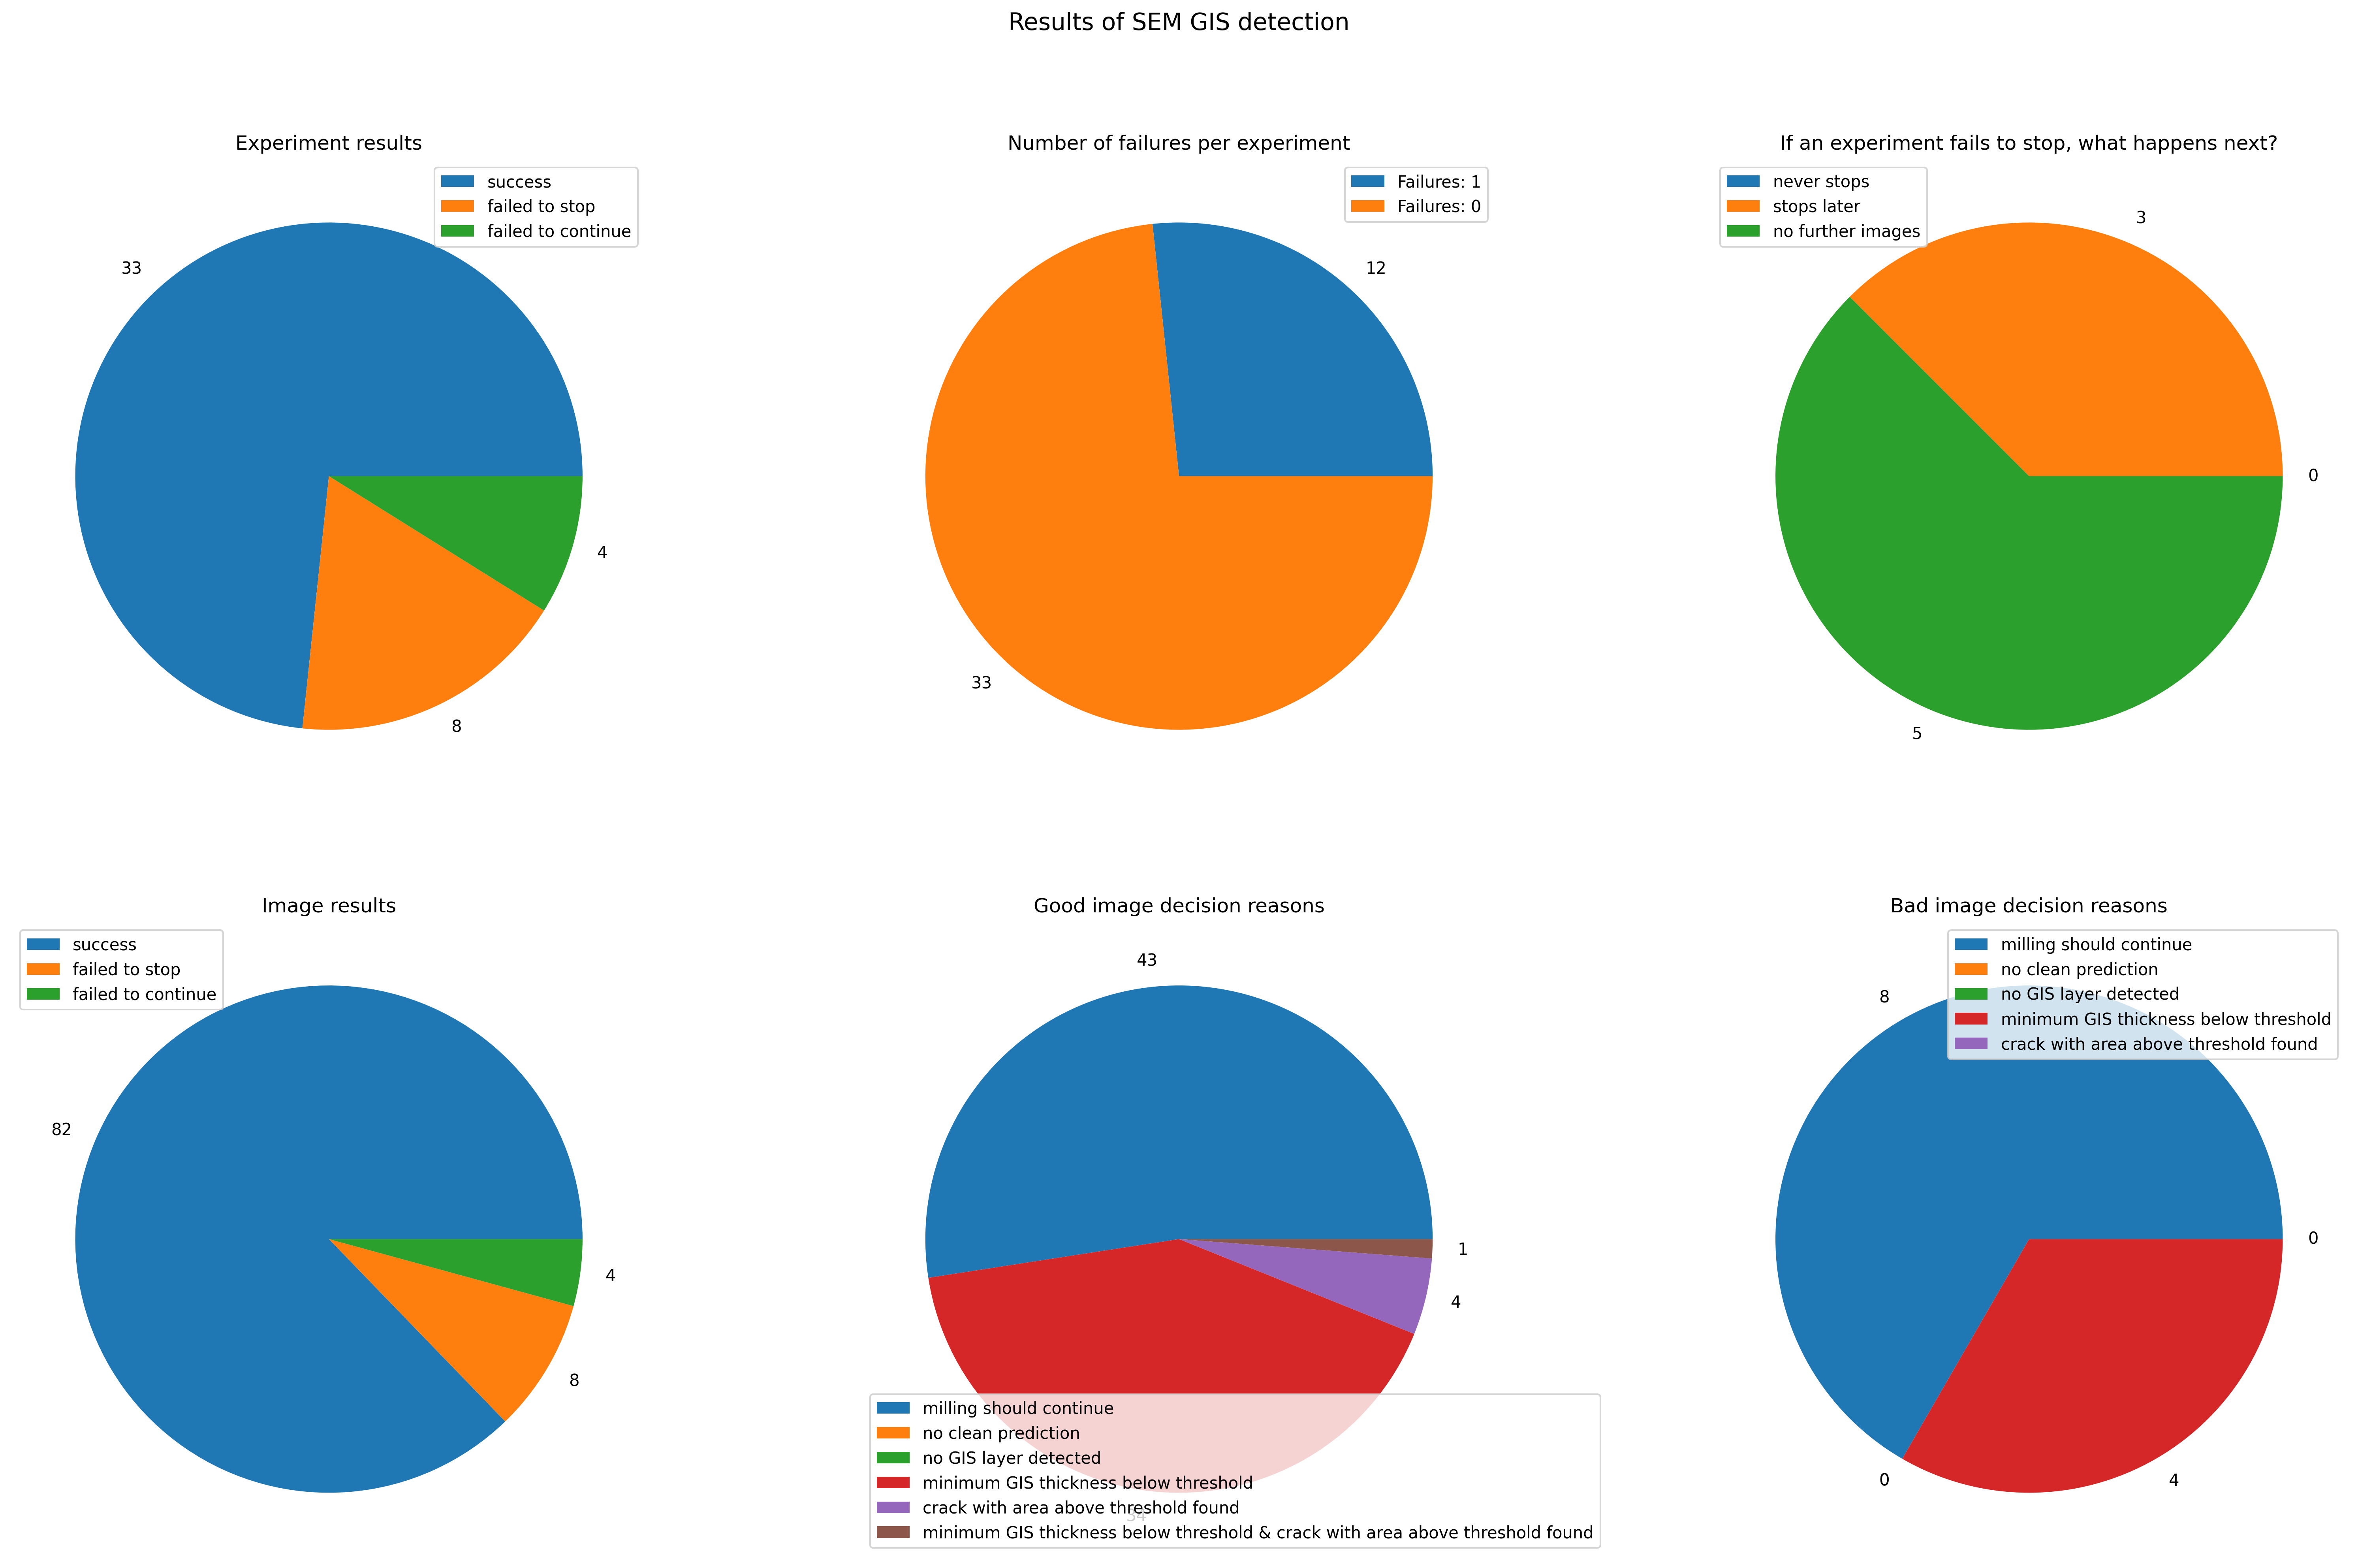

In [84]:
create_plots(results, output_path=results_plots_path)